In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests 
import plotly.express as px
import sqlite3



In [2]:


jobs = []

for page in range(1,21):   # 20 pages

    url = f"https://api.adzuna.com/v1/api/jobs/in/search/{page}?app_id=72289caf&app_key=00e89fcd5cce9555bdcb4494ded5322e&results_per_page=10"

    response = requests.get(url)
    data = response.json()

    for job in data["results"]:
        jobs.append({
        "title": job["title"],
        "company": job["company"]["display_name"],
        "location": job["location"]["display_name"],
        "category": job["category"]["label"],
        "description": job["description"]
        })

df = pd.DataFrame(jobs)

print("Total Jobs:", len(df))

df.head()

Total Jobs: 200


,title,company,location,category,description
0,Remote Finance Analyst,P&P Partner,India,Accounting & Finance Jobs,Fortune 500 Company | Fully Remote | Attractiv...
1,Java Engineer,Interas Labs,"Hyderabad, Telangana",IT Jobs,Company Description Interas Labs is an enginee...
2,Title Searcher,Coforge,"Bangalore, Karnataka",Healthcare & Nursing Jobs,About the Job Job Title: Title Search Speciali...
3,Manufacturing Engineer,Intralog Automation,"Vadodara, Gujarat",Manufacturing Jobs,Junior Manufacturing Engineer – Material Handl...
4,M365 Engineer,Persistent Systems,India,IT Jobs,About Position: We are seeking for M365 Engine...


In [3]:
df.to_csv("jobs_data.csv", index=False)

In [4]:

df = pd.read_csv("jobs_data.csv")

df.head(50)

,title,company,location,category,description
0,Associate Director HRBP - International voice ...,Sagility,"Hyderabad, Telangana",HR & Recruitment Jobs,Shift timings: 6 pm Onwards Location: Hyderaba...
1,Data Engineer,Hash Agile Technologies,"Coimbatore, Tamil Nadu",IT Jobs,Role: Data Engineer Location: Coimbatore We ar...
2,SAP PLM Functional Consultant,Infosys,"Hyderabad, Telangana",IT Jobs,About the Role We are seeking an experienced S...
3,"Manager, Treasury - Equity Investments, ACG Group",ACG World,"Mumbai, Maharashtra",Accounting & Finance Jobs,"Position Title: Manager, Treasury - Equity Inv..."
4,Finance Specialist,Capgemini,"Noida, Ghaziabad",Accounting & Finance Jobs,Greetings from Capgemini! We are conducting a ...
5,Senior Data Engineer,Quantiphi,"Chennai, Tamil Nadu",IT Jobs,Required Skill s: ● Bachelor’s degree in compu...
6,Oracle Billing - OCOMC,BT Group,"Bangalore, Karnataka",IT Jobs,About the Company We are a leading telecommuni...
7,Online Business Manager,Isha LIFE,"Coimbatore, Tamil Nadu",Sales Jobs,"Dear Candidate, We have a requirement for Ecom..."
8,Senior Manager- Sales (MICE),Thomas Cook India Limited,"Bangalore, Karnataka",IT Jobs,Please find the JD. Role - Senior Manager- Sal...
9,Machine Learning Engineer,"Lytx, Inc.","Bangalore, Karnataka",IT Jobs,Job Description Why Lytx?: As our Machine Lear...


In [5]:
df.columns

Index(['title', 'company', 'location', 'category', 'description'], dtype='object')

In [6]:
skills = [
"python","sql","excel","power bi","tableau","machine learning",
"data analysis","pandas","numpy","deep learning","aws","azure"
]

In [9]:
def extract_skills(description):

    found = []

    description = str(description).lower()

    for skill in skills:
        if skill in description:
            found.append(skill)

    return found


df["skills_found"] = df["description"].apply(extract_skills)

df.head(50)

,title,company,location,category,description,skills_found
0,Associate Director HRBP - International voice ...,Sagility,"Hyderabad, Telangana",HR & Recruitment Jobs,Shift timings: 6 pm Onwards Location: Hyderaba...,[]
1,Data Engineer,Hash Agile Technologies,"Coimbatore, Tamil Nadu",IT Jobs,Role: Data Engineer Location: Coimbatore We ar...,[]
2,SAP PLM Functional Consultant,Infosys,"Hyderabad, Telangana",IT Jobs,About the Role We are seeking an experienced S...,[]
3,"Manager, Treasury - Equity Investments, ACG Group",ACG World,"Mumbai, Maharashtra",Accounting & Finance Jobs,"Position Title: Manager, Treasury - Equity Inv...",[]
4,Finance Specialist,Capgemini,"Noida, Ghaziabad",Accounting & Finance Jobs,Greetings from Capgemini! We are conducting a ...,[]
5,Senior Data Engineer,Quantiphi,"Chennai, Tamil Nadu",IT Jobs,Required Skill s: ● Bachelor’s degree in compu...,[sql]
6,Oracle Billing - OCOMC,BT Group,"Bangalore, Karnataka",IT Jobs,About the Company We are a leading telecommuni...,[]
7,Online Business Manager,Isha LIFE,"Coimbatore, Tamil Nadu",Sales Jobs,"Dear Candidate, We have a requirement for Ecom...",[]
8,Senior Manager- Sales (MICE),Thomas Cook India Limited,"Bangalore, Karnataka",IT Jobs,Please find the JD. Role - Senior Manager- Sal...,[]
9,Machine Learning Engineer,"Lytx, Inc.","Bangalore, Karnataka",IT Jobs,Job Description Why Lytx?: As our Machine Lear...,[machine learning]


In [10]:
from collections import Counter

all_skills = []

for s in df["skills_found"]:
    all_skills.extend(s)

skill_counts = Counter(all_skills)

skill_counts

Counter({'excel': 14,
         'aws': 4,
         'python': 3,
         'sql': 2,
         'machine learning': 2,
         'data analysis': 2,
         'azure': 2})

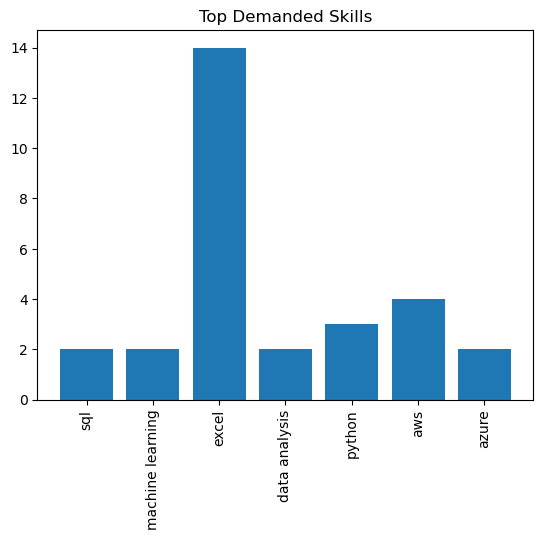

In [12]:

skills = dict(skill_counts)

plt.bar(skills.keys(), skills.values())

plt.xticks(rotation=90)

plt.title("Top Demanded Skills")

plt.show()

In [13]:
df.to_csv("job_market_analysis.csv", index=False)

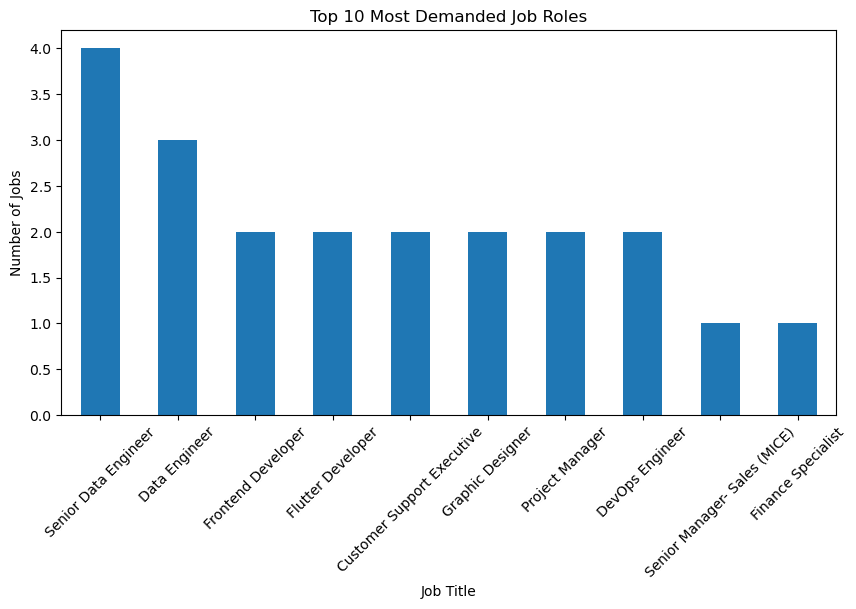

In [14]:
top_jobs = df["title"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_jobs.plot(kind="bar")

plt.title("Top 10 Most Demanded Job Roles")

plt.xlabel("Job Title")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

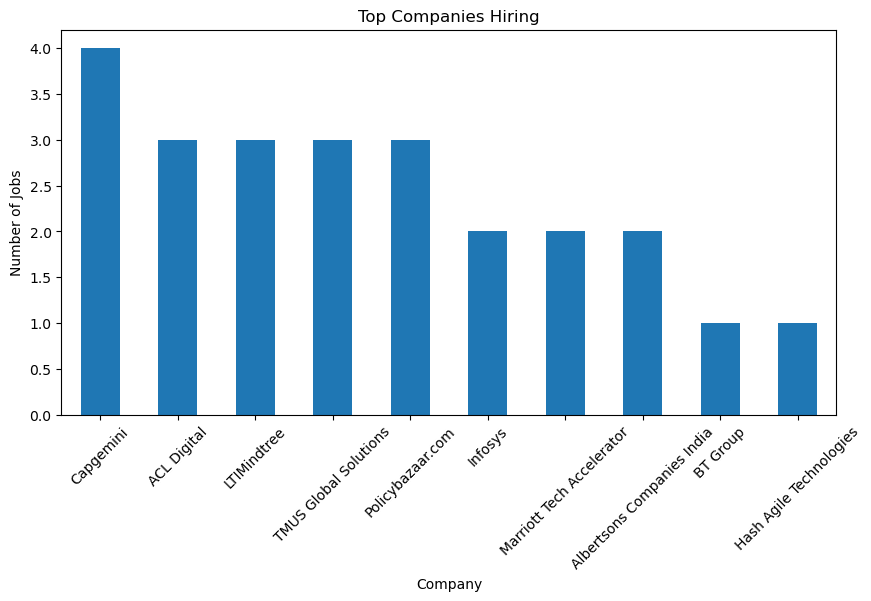

In [15]:
top_companies = df["company"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_companies.plot(kind="bar")

plt.title("Top Companies Hiring")

plt.xlabel("Company")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

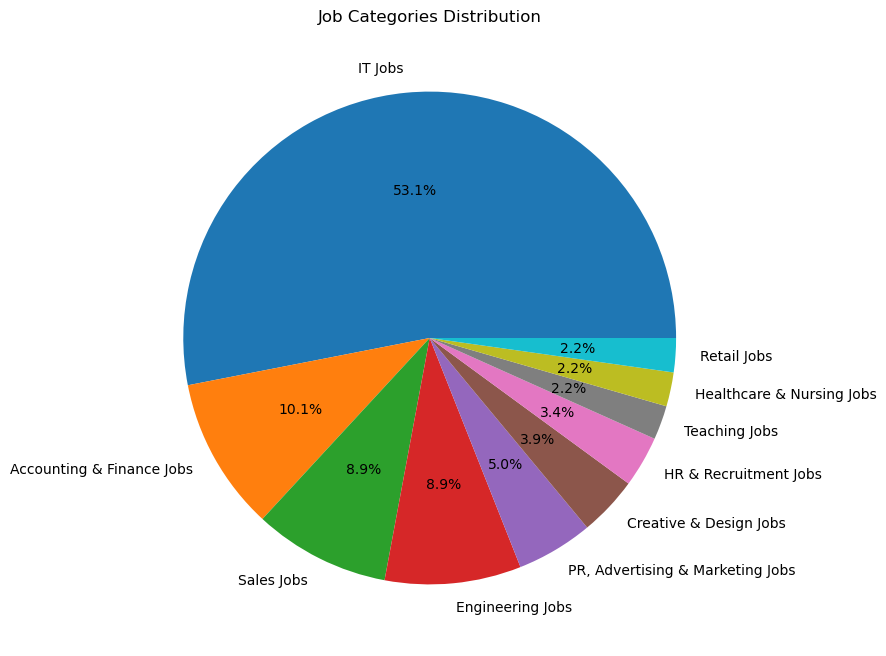

In [16]:
category_counts = df["category"].value_counts().head(10)

plt.figure(figsize=(8,8))

category_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Job Categories Distribution")

plt.ylabel("")

plt.show()

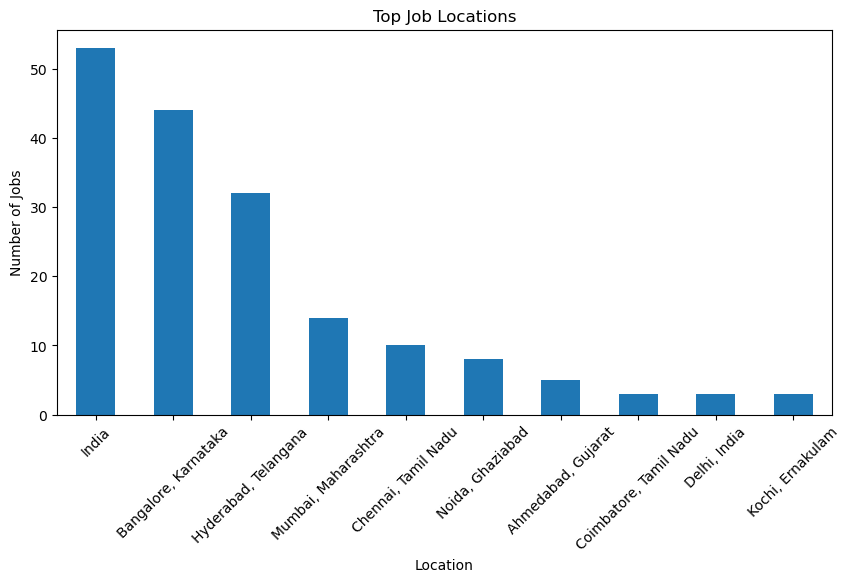

In [17]:
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_locations.plot(kind="bar")

plt.title("Top Job Locations")

plt.xlabel("Location")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

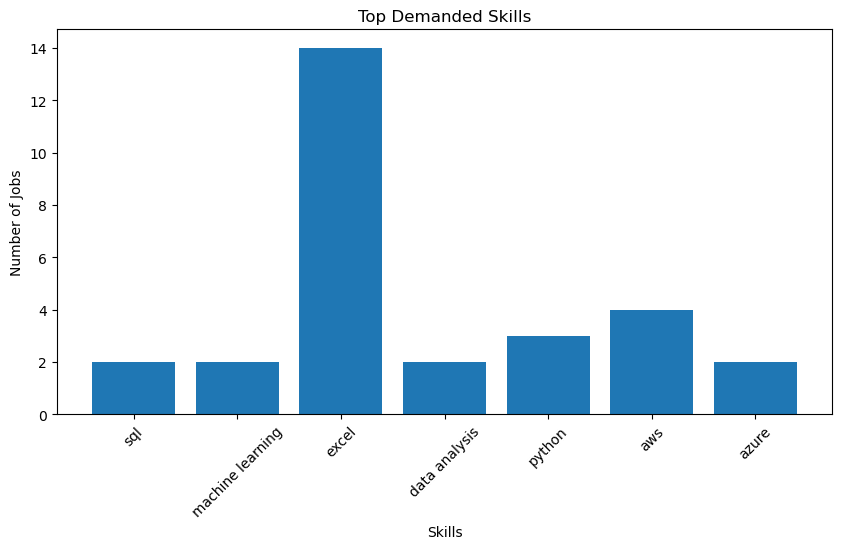

In [18]:
skills = dict(skill_counts)

plt.figure(figsize=(10,5))

plt.bar(skills.keys(), skills.values())

plt.title("Top Demanded Skills")

plt.xlabel("Skills")

plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)

plt.show()

In [19]:
print("Total Jobs Collected:", len(df))
print("Top Location:", df["location"].value_counts().idxmax())
print("Top Job Role:", df["title"].value_counts().idxmax())

Total Jobs Collected: 200
Top Location: India
Top Job Role: Senior Data Engineer
